In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

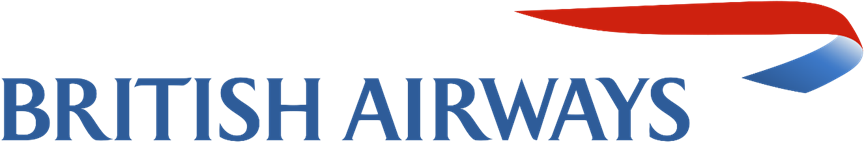

#My main idea with this notebook is to find the best grouping possible to estimate the proportion of clients of Tier 1, 2 and 3,  depending on that category.

In [2]:
flight_data = pd.read_excel("/content/British Airways Summer Schedule Dataset - Forage Data Science Task 1.xlsx")
flight_data.head(20)

,FLIGHT_DATE,FLIGHT_TIME,TIME_OF_DAY,AIRLINE_CD,FLIGHT_NO,DEPARTURE_STATION_CD,ARRIVAL_STATION_CD,ARRIVAL_COUNTRY,ARRIVAL_REGION,HAUL,AIRCRAFT_TYPE,FIRST_CLASS_SEATS,BUSINESS_CLASS_SEATS,ECONOMY_SEATS,TIER1_ELIGIBLE_PAX,TIER2_ELIGIBLE_PAX,TIER3_ELIGIBLE_PAX
0,2025-09-02,14:19:00,Afternoon,BA,BA5211,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,10,38
1,2025-06-10,06:42:00,Morning,BA,BA7282,LHR,LAX,USA,North America,LONG,B777,8,49,178,0,7,28
2,2025-10-27,15:33:00,Afternoon,BA,BA1896,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,11,40
3,2025-06-15,18:29:00,Evening,BA,BA5497,LHR,IST,Turkey,Europe,SHORT,A320,0,8,172,0,16,54
4,2025-08-25,20:35:00,Evening,BA,BA1493,LHR,FRA,Germany,Europe,SHORT,A320,0,13,167,0,6,27
5,2025-07-12,19:08:00,Evening,BA,BA4954,LHR,VIE,Austria,Europe,SHORT,A320,0,20,160,0,6,27
6,2025-09-16,21:44:00,Evening,BA,BA9840,LHR,AMS,Netherlands,Europe,SHORT,A320,0,20,160,0,16,55
7,2025-04-24,14:50:00,Afternoon,BA,BA7116,LHR,ORD,USA,North America,LONG,A350,0,56,275,1,12,42
8,2025-05-17,12:13:00,Lunchtime,BA,BA4424,LHR,FRA,Germany,Europe,SHORT,A320,0,17,163,0,5,23
9,2025-05-01,09:55:00,Morning,BA,BA4878,LHR,IST,Turkey,Europe,SHORT,A320,0,4,176,1,11,39


In [3]:
import datetime
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(0, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(3, 0, 0)), "departure_interval"] = "12am-3am"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(3, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(6, 0, 0)), "departure_interval"] = "3am-6am"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(6, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(9, 0, 0)), "departure_interval"] = "6am-9am"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(9, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(12, 0, 0)), "departure_interval"] = "9am-12pm"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(12, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(15, 0, 0)), "departure_interval"] = "12pm-3pm"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(15, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(18, 0, 0)), "departure_interval"] = "3pm-6pm"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(18, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(21, 0, 0)), "departure_interval"] = "6pm-9pm"
flight_data.loc[(flight_data['FLIGHT_TIME'] >= datetime.time(21, 0, 0)) & (flight_data['FLIGHT_TIME'] < datetime.time(23, 59, 0)), "departure_interval"] = "9pm-12am"

In [9]:
view2 = flight_data.groupby(["departure_interval","ARRIVAL_REGION"])[["TIER1_ELIGIBLE_PAX","TIER2_ELIGIBLE_PAX","TIER3_ELIGIBLE_PAX"]].mean()
view2


TIER1_ELIGIBLE_PAX  TIER2_ELIGIBLE_PAX  TIER3_ELIGIBLE_PAX
departure_interval ARRIVAL_REGION                                                            
12pm-3pm           Asia                      0.483051            7.864407           30.262712
                   Europe                    0.705561            8.064722           30.713765
                   Middle East               0.649573            7.948718           30.358974
                   North America             0.518779            8.053991           30.586854
3pm-6pm            Asia                      0.467890            8.302752           31.247706
                   Europe                    0.587719            7.755361           29.854776
                   Middle East               0.553719            7.735537           29.561983
                   North America             0.612836            8.045549           30.774327
6am-9am            Asia                      0.637168            7.929204           30.230088
                   Europe                    0.604146            7.806515           30.037512
                   Middle East               0.572414            7.572414           29.124138
                   North America             0.572008            8.231237           31.375254
6pm-9pm            Asia                      0.550000            7.933333           30.500000
                   Europe                    0.598881            7.915112           30.294776
                   Middle East               0.618321            7.465649           28.900763
                   North America             0.570796            7.942478           30.451327
9am-12pm           Asia                      0.593985            7.473684           29.150376
                   Europe                    0.619318            7.880682           30.232955
                   Middle East               0.538462            8.807692           33.096154
                   North America             0.642706            8.319239           31.564482
9pm-12am           Asia                      0.627907            7.558140           29.069767
                   Europe                    0.579466            8.160338           31.040788
                   Middle East               0.700000            7.785714           29.542857
                   North America             0.688822            7.764350           29.776435

In [10]:
styled_df = (
    view2.style
      .set_table_styles([
          # Cabeçalho
          {'selector': 'th',
           'props': [
               ('background-color', '#1f4e79'),
               ('color', 'white'),
               ('font-size', '14px'),
               ('text-align', 'center'),
               ('padding', '10px'),
               ('border', '1px solid black')
           ]},

          # Células
          {'selector': 'td',
           'props': [
               ('padding', '10px'),
               ('border', '1px solid #cccccc'),
               ('text-align', 'center')
           ]},

          # Tabela inteira
          {'selector': 'table',
           'props': [
               ('border-collapse', 'collapse'),
               ('width', '100%')
           ]}
      ])
      .set_properties(**{
          'font-size': '13px'
      })
)

styled_df

As we can see here, we now have the estimate of percentage of clients with eligibility of tier 1, 2 and 3, based on the departure_interval and the arrival_region. This is the best grouping possible, given the information we have, because it gives a general and also precise estimation of the percentage number of client's and his respective tier eligibility